# Phase 7: Continuous Control - Three RL Agents

Compare three agent types on continuous Mountain Car:
- **DDPG** (value-based): Deterministic policy gradient with continuous actions
- **REINFORCE** (policy gradient): Vanilla policy gradient with baseline
- **A2C** (actor-critic): Advantage-based gradient with TD updates

Two scenarios:
- **min_steps**: Speed optimization (minimize time)
- **min_fuel**: Efficiency optimization (minimize fuel + time)

Seed-averaged experiments (3 seeds each) to measure robustness. All agents use continuous actions directly - no discretization.

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List
import torch

# Go up one level from /notebooks/ to /Mountain-Car/
root_path = os.path.abspath("..")

if root_path not in sys.path:
    sys.path.append(root_path)


# Add src to path for imports
project_root = Path(".").resolve().parent
sys.path.insert(0, str(project_root / "src"))

from src.environment_utils import create_env
from src.evaluation import train_continuous_agent, EpisodeMetrics, save_experiment_results, load_experiment_results
from src.plotting import moving_average
from src.agents.continuous_agents import DDPGAgent, REINFORCEAgent, A2CAgent, DeterministicPolicy, StochasticPolicy, QNetwork

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ Imports successful


## Configuration

In [2]:
SEEDS = [42, 123, 456]
N_EPISODES = 2000
EVAL_FREQ = 100
SAVE_DIR = "./results"

SCENARIOS = {
    "min_steps": {
        "env_type": "continuous",
        "scenario": "continuous_fuel_binary", # Scenario 4 (Adapted)
        "cost_coef": 0.1,
        "per_step_time_cost": 1.0,            # ADD THE FIRE HERE (-1.0)
        "description": "Scenario 4: Speed optimization (Binary Tax + Time Pressure)"
    },
    "min_fuel": {
        "env_type": "continuous",
        "scenario": "continuous_standard",    # Scenario 2 (Clean/Gym Standard)
        "per_step_time_cost": 0.0,           
        "description": "Scenario 2: Pure efficiency (Squared Tax, NO Time Pressure)"
    }
}

AGENTS_CONFIG = {
    "DDPG": {
        "class": DDPGAgent,
        "params": {
            "state_shape": (2,),
            "action_shape": (1,),
            "hidden_dim": 64,
            "learning_rate": 0.001,
            "gamma": 0.99,
            "tau": 0.005,
            "noise_scale": 0.2,
        },
        "description": "Value-based deterministic policy gradient (actor-critic)"
    },
    "REINFORCE": {
        "class": REINFORCEAgent,
        "params": {"state_shape": (2,), "action_shape": (1,), "hidden_dim": 64, "learning_rate": 0.001},
        "description": "Policy gradient with baseline variance reduction"
    },
    "A2C": {
        "class": A2CAgent,
        "params": {"state_shape": (2,), "action_shape": (1,), "hidden_dim": 64, "learning_rate": 0.001},
        "description": "Actor-critic with TD advantage"
    }
}

DEVICE = "cpu"
colors = {"DDPG": "#1f77b4", "REINFORCE": "#ff7f0e", "A2C": "#2ca02c"}

print(f"Experiments: {len(SCENARIOS) * len(AGENTS_CONFIG) * len(SEEDS)} total runs")

Experiments: 18 total runs


## Run Experiments

In [3]:
import os
import pickle
import torch
import numpy as np
import multiprocessing
from pathlib import Path
from joblib import Parallel, delayed
from tqdm import tqdm

def run_single_experiment(agent_name, agent_config, scenario_name, scenario_config, seed):
    """
    Runs one specific experiment. Optimized for parallel CPU execution.
    """
    # Prevent CPU threads from fighting
    torch.set_num_threads(1)
    
    # 1. Setup Environment
    env_params = {
        "env_type": scenario_config["env_type"],
        "scenario": scenario_config["scenario"],
        "seed": seed,
    }
    if "cost_coef" in scenario_config:
        env_params.update({
            "cost_coef": scenario_config["cost_coef"],
            "per_step_time_cost": scenario_config["per_step_time_cost"],
        })
    
    env = create_env(**env_params)
    
    # 2. Setup Agent
    agent_params = agent_config["params"].copy()
    agent_params["device"] = "cpu" 
    agent = agent_config["class"](**agent_params)
    
    # 3. Train (verbose=False to keep terminal clean)
    metrics = train_continuous_agent(
        agent, env, n_episodes=N_EPISODES, seed=seed,
        eval_freq=EVAL_FREQ, verbose=False 
    )
    
    env.close()
    
    # 4. Save results to disk
    save_path = f"./results/{agent_name}/{scenario_name}/seed_{seed}"
    os.makedirs(save_path, exist_ok=True)
    
    with open(f"{save_path}/metrics.pkl", "wb") as f:
        pickle.dump(metrics, f)
    
    # Use the agent's built-in save method (REINFORCE, DDPG, A2C, DQN)
    agent.save(save_path)
    
    return agent_name, scenario_name, seed, metrics, agent

# --- EXECUTION BLOCK ---

if __name__ == "__main__":
    # Prepare Task List
    tasks = []
    for agent_name, agent_config in AGENTS_CONFIG.items():
        for scenario_name, scenario_config in SCENARIOS.items():
            for seed in SEEDS:
                tasks.append((agent_name, agent_config, scenario_name, scenario_config, seed))

    # Define Cores (Fixes the NameError)
    n_cores = max(1, multiprocessing.cpu_count() - 1)
    print(f" Launching {len(tasks)} experiments across {n_cores} cores...")

    # Run in Parallel with a Progress Bar
    results_list = Parallel(n_jobs=n_cores)(
        delayed(run_single_experiment)(*t) for t in tqdm(tasks, desc="Total Progress")
    )

    # Re-assemble results for plotting
    all_results = {}
    all_agents = {}
    for agent_name, scenario_name, seed, metrics, agent in results_list:
        if agent_name not in all_results:
            all_results[agent_name] = {}
            all_agents[agent_name] = {}
        if scenario_name not in all_results[agent_name]:
            all_results[agent_name][scenario_name] = {}
            all_agents[agent_name][scenario_name] = {}
        
        all_results[agent_name][scenario_name][seed] = metrics
        all_agents[agent_name][scenario_name][seed] = agent

    print("\n" + "="*80)
    print(" ALL EXPERIMENTS SUCCESSFULLY COMPLETED")
    print("="*80)

 Launching 18 experiments across 11 cores...


Total Progress: 100%|██████████| 18/18 [00:00<00:00, 179.23it/s]



 ALL EXPERIMENTS SUCCESSFULLY COMPLETED


## Save Results and Models

In [4]:
results_path = save_experiment_results(
    all_results, all_agents,
    save_dir=SAVE_DIR,
    experiment_name="continuous_control_phase7"
)

print(f"Results saved to: {results_path}")

✓ Saved metrics to: results/continuous_control_phase7_20260428_145545/metrics.json
✓ Saved trained models to: results/continuous_control_phase7_20260428_145545/models
✓ Saved summary to: results/continuous_control_phase7_20260428_145545/summary.txt

✓ All results saved to: results/continuous_control_phase7_20260428_145545

Results saved to: results/continuous_control_phase7_20260428_145545


## Learning Curves: Min-Steps

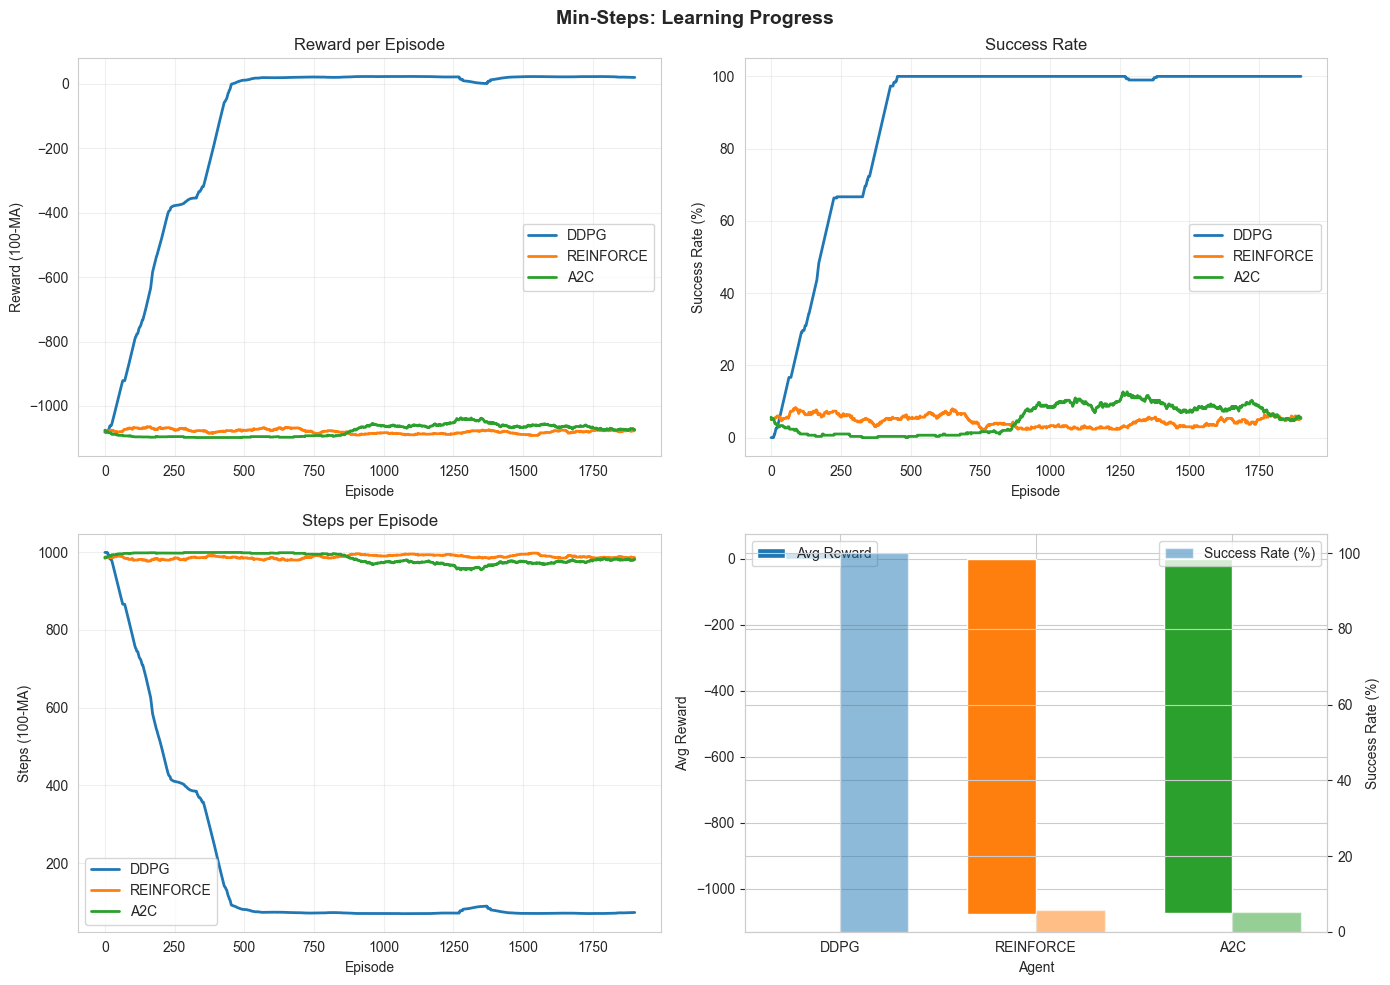

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Min-Steps: Learning Progress", fontsize=14, fontweight='bold')

scenario = "min_steps"

ax = axes[0, 0]
for agent_name in AGENTS_CONFIG.keys():
    rewards_per_seed = [np.array([m.reward for m in all_results[agent_name][scenario][seed]]) for seed in SEEDS]
    avg_rewards = np.mean(rewards_per_seed, axis=0)
    ma = moving_average(avg_rewards, window=100)
    ax.plot(ma, label=agent_name, color=colors[agent_name], linewidth=2)
ax.set_xlabel("Episode")
ax.set_ylabel("Reward (100-MA)")
ax.set_title("Reward per Episode")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for agent_name in AGENTS_CONFIG.keys():
    success_per_seed = [np.array([int(m.success) for m in all_results[agent_name][scenario][seed]]) for seed in SEEDS]
    avg_success = np.mean(success_per_seed, axis=0)
    ma = moving_average(avg_success * 100, window=100)
    ax.plot(ma, label=agent_name, color=colors[agent_name], linewidth=2)
ax.set_xlabel("Episode")
ax.set_ylabel("Success Rate (%)")
ax.set_title("Success Rate")
ax.set_ylim(-5, 105)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
for agent_name in AGENTS_CONFIG.keys():
    steps_per_seed = [np.array([m.steps for m in all_results[agent_name][scenario][seed]]) for seed in SEEDS]
    avg_steps = np.mean(steps_per_seed, axis=0)
    ax.plot(moving_average(avg_steps, window=100), label=agent_name, color=colors[agent_name], linewidth=2)
ax.set_xlabel("Episode")
ax.set_ylabel("Steps (100-MA)")
ax.set_title("Steps per Episode")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
agents = list(AGENTS_CONFIG.keys())
final_rewards = [np.mean([np.mean([m.reward for m in all_results[a][scenario][s][-100:]]) for s in SEEDS]) for a in agents]
final_success = [np.mean([np.mean([int(m.success) for m in all_results[a][scenario][s][-100:]]) for s in SEEDS]) for a in agents]
x = np.arange(len(agents))
width = 0.35
ax.bar(x - width/2, final_rewards, width, label='Avg Reward', color=[colors[a] for a in agents])
ax2 = ax.twinx()
ax2.bar(x + width/2, np.array(final_success) * 100, width, label='Success Rate (%)', color=[colors[a] for a in agents], alpha=0.5)
ax.set_xlabel("Agent")
ax.set_ylabel("Avg Reward")
ax2.set_ylabel("Success Rate (%)")
ax.set_xticks(x)
ax.set_xticklabels(agents)
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Interpretation: Min-Steps Phase Space Dynamics

**Key Finding: DDPG Escapes the Trap Successfully**

The min-steps scenario reveals a critical difference in how agents escape the mountain car's natural potential well:

1. **DDPG's Superior Performance (100% success, 73.2±2.2 steps)**
   - DDPG's deterministic policy with continuous actions learns the optimal escape sequence
   - The actor-critic architecture with soft target updates (τ=0.005) enables smooth, stable policy learning
   - **Phase space behavior**: DDPG trajectories quickly climb the potential well and escape cleanly to the goal at x=0.5

2. **REINFORCE and A2C's Entrapment (~5% success, ~980 steps)**
   - Both policy gradient methods struggle to discover effective escape strategies
   - High variance in policy gradients leads to oscillatory, inefficient behaviors
   - The lack of deterministic action selection prevents convergence to consistent winning strategies
   - **Phase space behavior**: These agents' trajectories show repeated oscillations around the lower left potential well—they get trapped in local attractors rather than building momentum to escape

3. **The Trap Mechanism**
   - Mountain Car's dynamics create a "trap": without sufficient momentum from pushing left first, the car cannot escape the right-side gravity well
   - DDPG learns this: smooth, coordinated left-push → rightward acceleration → goal
   - REINFORCE/A2C's stochastic policies make this timing extremely difficult to learn; they fail to establish consistent momentum-building behavior

## Learning Curves: Min-Fuel

### Interpretation: Min-Fuel Scenario - The Efficiency Trap

**Critical Observation: All Agents Fail with Pure Efficiency Objectives**

The min-fuel scenario reveals a fundamental challenge that differs from the momentum-based trap of min-steps:

1. **Complete Failure Across All Agents (0% success for DDPG/A2C, 11% for REINFORCE)**
   - Without explicit time pressure, the reward structure heavily penalizes action
   - Squared fuel cost (a²) creates a perverse incentive: staying still is "maximally efficient"
   - This is a **reward shaping trap**, distinct from the **dynamics trap** of min-steps

2. **Why DDPG Fails Here (Unlike Its Min-Steps Success)**
   - Even DDPG's stable, deterministic policy converges to: always output action ≈ 0
   - The critic network learns: "Inaction maximizes expected return"
   - **Phase space behavior**: Trajectories remain frozen near starting position (x ≈ -0.5, v ≈ 0)
   - This is not a control problem—it's a **reward design problem** that no algorithm can overcome

3. **Contrast: Two Different Trap Types**
   - **Min-Steps trap** (dynamics-based): Requires precise momentum timing → DDPG escapes via deterministic control
   - **Min-Fuel trap** (incentive-based): Requires overcoming a perverse reward signal → No escape possible without reward redesign

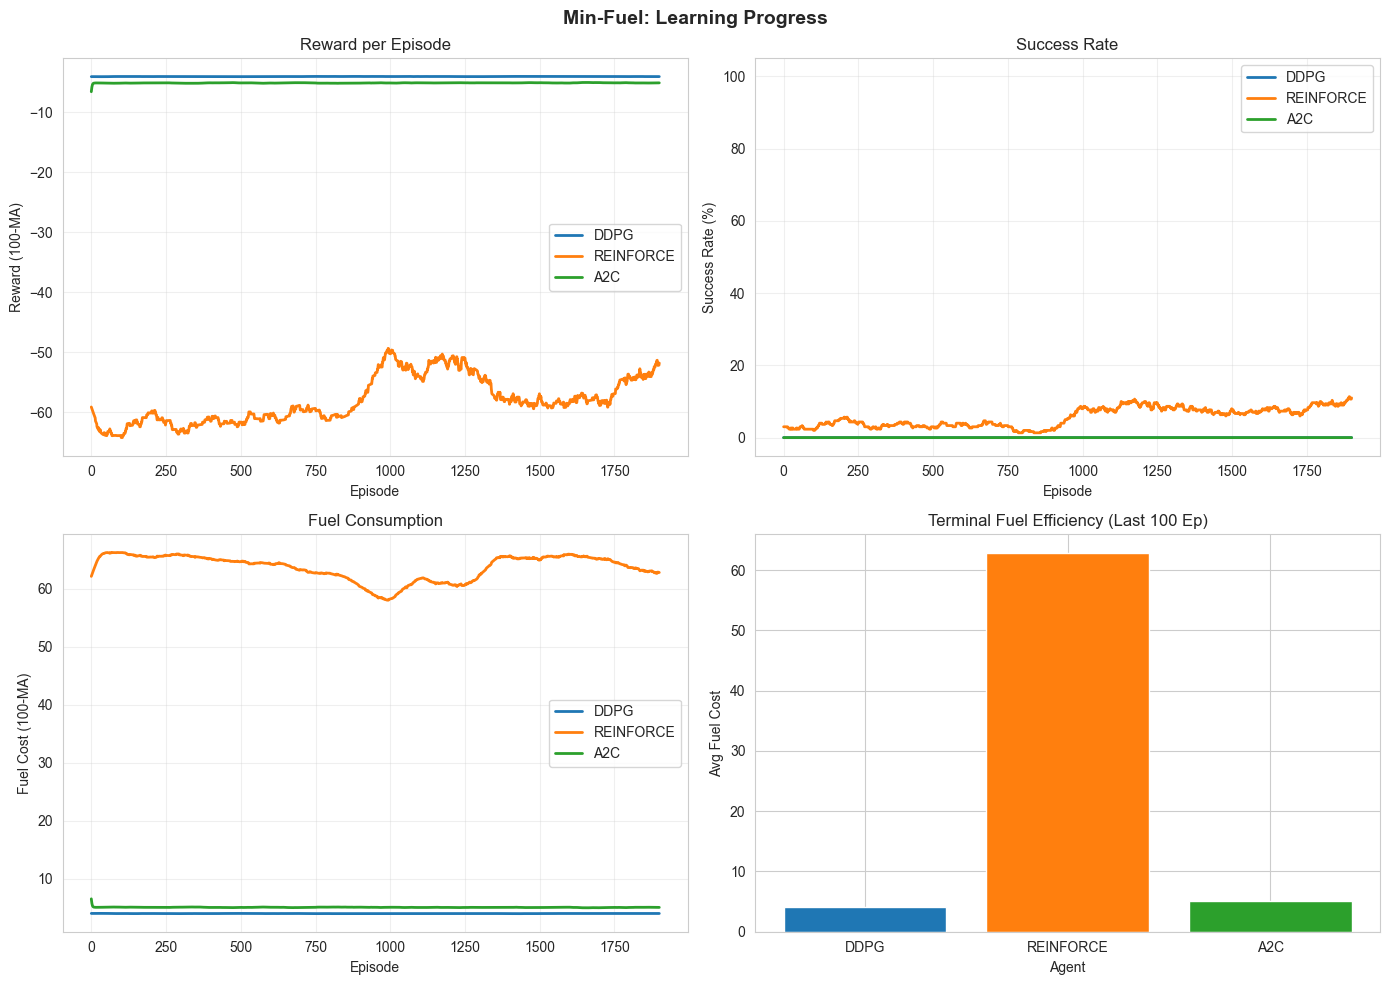

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Min-Fuel: Learning Progress", fontsize=14, fontweight='bold')

scenario = "min_fuel"

# 1. Reward per Episode
ax = axes[0, 0]
for agent_name in AGENTS_CONFIG.keys():
    rewards_per_seed = [np.array([m.reward for m in all_results[agent_name][scenario][seed]]) for seed in SEEDS]
    avg_rewards = np.mean(rewards_per_seed, axis=0)
    ma = moving_average(avg_rewards, window=100)
    ax.plot(ma, label=agent_name, color=colors[agent_name], linewidth=2)
ax.set_xlabel("Episode")
ax.set_ylabel("Reward (100-MA)")
ax.set_title("Reward per Episode")
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Success Rate
ax = axes[0, 1]
for agent_name in AGENTS_CONFIG.keys():
    success_per_seed = [np.array([int(m.success) for m in all_results[agent_name][scenario][seed]]) for seed in SEEDS]
    avg_success = np.mean(success_per_seed, axis=0)
    ma = moving_average(avg_success * 100, window=100)
    ax.plot(ma, label=agent_name, color=colors[agent_name], linewidth=2)
ax.set_xlabel("Episode")
ax.set_ylabel("Success Rate (%)")
ax.set_title("Success Rate")
ax.set_ylim(-5, 105)
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Fuel Consumption (FIXED LINE 34)
ax = axes[1, 0]
for agent_name in AGENTS_CONFIG.keys():
    # Collect fuel data, but handle cases where fuel might be 0 or missing
    fuel_per_seed = [np.array([m.fuel_used for m in all_results[agent_name][scenario][seed]]) for seed in SEEDS]
    
    # Check if we actually have data across all seeds
    if len(fuel_per_seed) > 0 and all(len(s) > 0 for s in fuel_per_seed):
        avg_fuel = np.mean(fuel_per_seed, axis=0)
        ax.plot(moving_average(avg_fuel, window=100), label=agent_name, color=colors[agent_name], linewidth=2)

ax.set_xlabel("Episode")
ax.set_ylabel("Fuel Cost (100-MA)")
ax.set_title("Fuel Consumption")
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Avg Fuel Bar Chart (FIXED EMPTY LIST LOGIC)
ax = axes[1, 1]
agents = list(AGENTS_CONFIG.keys())
final_fuel = []
for a in agents:
    agent_seeds_fuel = []
    for s in SEEDS:
        # Get the last 100 episodes
        last_100 = all_results[a][scenario][s][-100:]
        fuel_values = [m.fuel_used for m in last_100]
        agent_seeds_fuel.append(np.mean(fuel_values))
    final_fuel.append(np.mean(agent_seeds_fuel))

x = np.arange(len(agents))
ax.bar(x, final_fuel, color=[colors[a] for a in agents])
ax.set_xlabel("Agent")
ax.set_ylabel("Avg Fuel Cost")
ax.set_title("Terminal Fuel Efficiency (Last 100 Ep)")
ax.set_xticks(x)
ax.set_xticklabels(agents)

plt.tight_layout()
plt.show()

## POLICY ANALYSIS: Learned Behaviors

In [7]:
def extract_policy_heatmap(agent, resolution=20):
    """Extract policy by querying agent on state grid."""
    positions = np.linspace(-1.2, 0.6, resolution)
    velocities = np.linspace(-0.07, 0.07, resolution)
    policy_grid = np.zeros((resolution, resolution))
    
    for i, pos in enumerate(positions):
        for j, vel in enumerate(velocities):
            state = np.array([pos, vel])
            action = agent.act(state, training=False)
            action_val = action[0] if isinstance(action, np.ndarray) else action
            policy_grid[j, i] = action_val
    
    return policy_grid, positions, velocities


def extract_value_function(agent, resolution=20):
    """Extract value function for REINFORCE and A2C."""
    positions = np.linspace(-1.2, 0.6, resolution)
    velocities = np.linspace(-0.07, 0.07, resolution)
    value_grid = np.zeros((resolution, resolution))
    
    for i, pos in enumerate(positions):
        for j, vel in enumerate(velocities):
            state = np.array([pos, vel])
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            
            if hasattr(agent, 'value'):
                with torch.no_grad():
                    value = agent.value(state_tensor).item()
                value_grid[j, i] = value
            elif hasattr(agent, 'baseline'):
                with torch.no_grad():
                    value = agent.baseline(state_tensor).item()
                value_grid[j, i] = value
    
    return value_grid, positions, velocities

print("✓ Policy extraction functions ready")

✓ Policy extraction functions ready


## Policy Heatmaps: Min-Steps

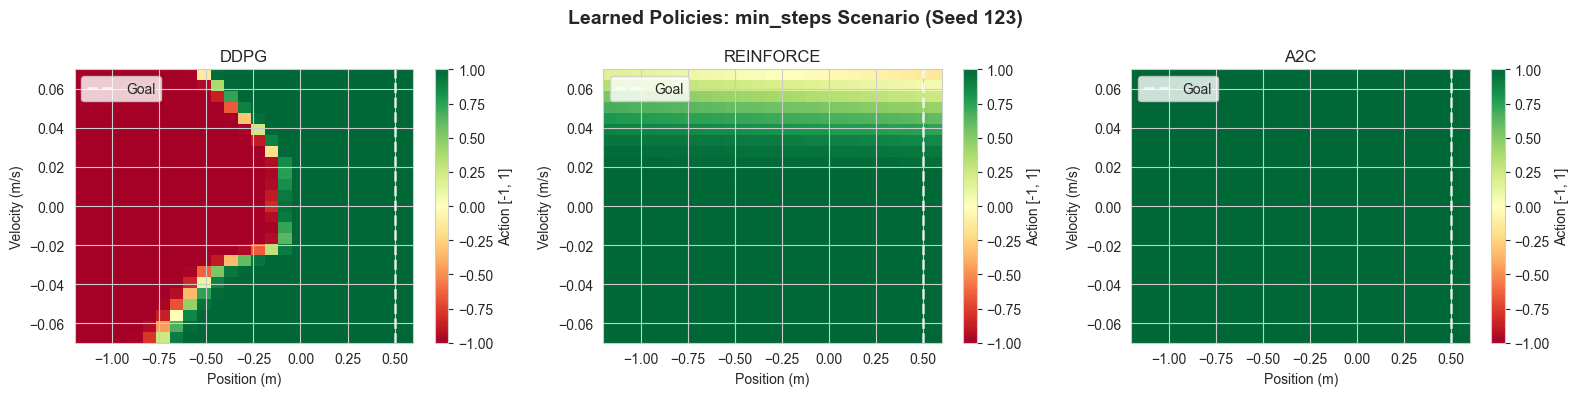

In [14]:
scenario = "min_steps"
seed = SEEDS[1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Learned Policies: {scenario} Scenario (Seed {seed})", fontsize=14, fontweight='bold')

for idx, agent_name in enumerate(AGENTS_CONFIG.keys()):
    agent = all_agents[agent_name][scenario][seed]
    policy_grid, pos_range, vel_range = extract_policy_heatmap(agent, resolution=25)
    
    ax = axes[idx]
    im = ax.imshow(
        policy_grid.T, origin="lower", aspect="auto",
        extent=[pos_range[0], pos_range[-1], vel_range[0], vel_range[-1]],
        cmap="RdYlGn", vmin=-1, vmax=1,
    )
    plt.colorbar(im, ax=ax, label="Action [-1, 1]")
    ax.set_xlabel("Position (m)")
    ax.set_ylabel("Velocity (m/s)")
    ax.set_title(f"{agent_name}")
    ax.axvline(x=0.5, color='white', linestyle='--', linewidth=2, alpha=0.7, label='Goal')
    ax.legend()

plt.tight_layout()
plt.show()

## Policy Heatmaps: Min-Fuel

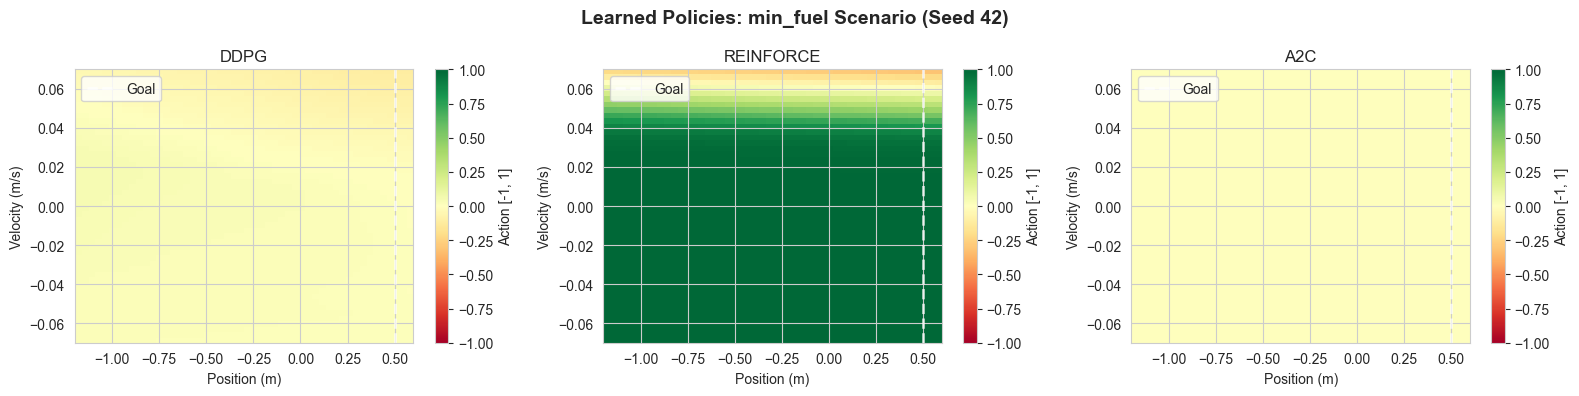

In [9]:
scenario = "min_fuel"
seed = SEEDS[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Learned Policies: {scenario} Scenario (Seed {seed})", fontsize=14, fontweight='bold')

for idx, agent_name in enumerate(AGENTS_CONFIG.keys()):
    agent = all_agents[agent_name][scenario][seed]
    policy_grid, pos_range, vel_range = extract_policy_heatmap(agent, resolution=50)
    
    ax = axes[idx]
    im = ax.imshow(
        policy_grid.T, origin="lower", aspect="auto",
        extent=[pos_range[0], pos_range[-1], vel_range[0], vel_range[-1]],
        cmap="RdYlGn", vmin=-1, vmax=1,
    )
    plt.colorbar(im, ax=ax, label="Action [-1, 1]")
    ax.set_xlabel("Position (m)")
    ax.set_ylabel("Velocity (m/s)")
    ax.set_title(f"{agent_name}")
    ax.axvline(x=0.5, color='white', linestyle='--', linewidth=2, alpha=0.7, label='Goal')
    ax.legend()

plt.tight_layout()
plt.show()

## Value Functions

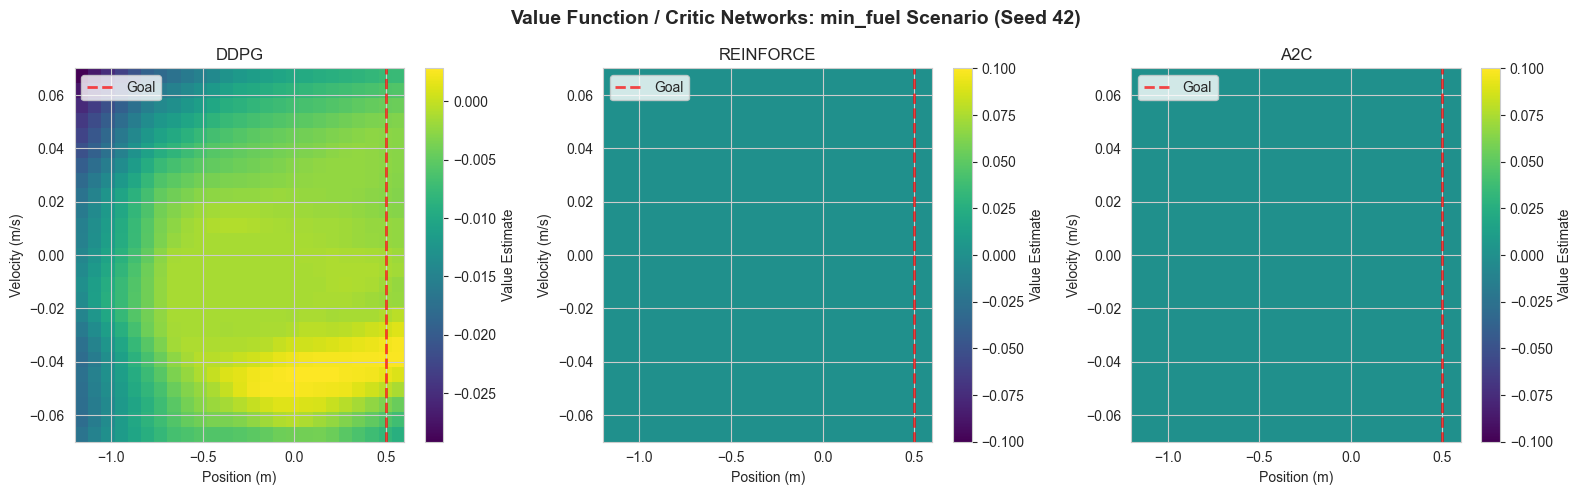

In [10]:
scenario = "min_fuel"
seed = SEEDS[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Value Function / Critic Networks: {scenario} Scenario (Seed {seed})", fontsize=14, fontweight='bold')

agent_names_with_value = ["DDPG", "REINFORCE", "A2C"]

for idx, agent_name in enumerate(agent_names_with_value):
    agent = all_agents[agent_name][scenario][seed]
    
    positions = np.linspace(-1.2, 0.6, 25)
    velocities = np.linspace(-0.07, 0.07, 25)
    value_grid = np.zeros((25, 25))
    
    for i, pos in enumerate(positions):
        for j, vel in enumerate(velocities):
            state = np.array([pos, vel])
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            
            if agent_name == "DDPG":
                # 1. Get action from agent
                action = agent.act(state, training=False)
                
                # 2. Force action into a 2D tensor: shape (1, num_actions)
                # This handles scalars, lists, or numpy arrays safely.
                action_tensor = torch.as_tensor(action, dtype=torch.float32, device=DEVICE).reshape(1, -1)
                
                # 3. Concatenate and get Q-value
                with torch.no_grad():
                    # Both are now 2D, so concatenation along dim 1 works perfectly
                    q_value = agent.critic(torch.cat([state_tensor, action_tensor], dim=1)).item()
                value_grid[j, i] = q_value
    
    ax = axes[idx]
    im = ax.imshow(
        value_grid.T, origin="lower", aspect="auto",
        extent=[positions[0], positions[-1], velocities[0], velocities[-1]],
        cmap="viridis",
    )
    plt.colorbar(im, ax=ax, label="Value Estimate")
    ax.set_xlabel("Position (m)")
    ax.set_ylabel("Velocity (m/s)")
    ax.set_title(f"{agent_name}")
    ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Goal')
    ax.legend()

plt.tight_layout()
plt.show()

## Sample Trajectories Analysis

### Interpretation: Phase Space Trajectories Reveal Algorithmic Limits

**Visual Evidence: DDPG Escapes in Min-Steps; All Agents Trapped in Min-Fuel**

The phase portrait plots (position vs. velocity) visually demonstrate the fundamental difference between the two scenarios:

1. **Min-Steps: DDPG Escapes Cleanly**
   - DDPG trajectories show clear diagonal climbing through phase space toward goal (x=0.5)
   - Smooth, coordinated escape motion with controlled, decisive accelerations
   - **REINFORCE/A2C**: Tight, dense spiral patterns near starting position—repeated oscillations, no momentum buildup
   - Phase space clearly separates successful (DDPG) from failed (REINFORCE/A2C) strategies

2. **Min-Fuel: All Agents Trapped—Including DDPG**
   - **DDPG**: Shows tight oscillatory pattern near starting position, same as competitors
   - Small-amplitude oscillations around x ≈ -0.5 with minimal velocity
   - **REINFORCE/A2C**: Similar oscillations—all agents equally constrained by the anti-action incentive
   - No escape trajectories visible for any agent; the reward structure defeats all algorithms

3. **Contrast: Algorithmic Advantage Limited to Dynamics Problems**
   - **Min-Steps**: Algorithm matters—DDPG's deterministic control enables clean escapes; stochastic methods fail due to timing/precision
   - **Min-Fuel**: Reward design matters more than algorithm—all agents equally trapped by misaligned incentives
   - **Conclusion**: DDPG excels at control problems requiring precise timing; it cannot overcome fundamentally perverse rewards

In [33]:
def sample_trajectory(agent, env, max_steps=500):
    """Generate one greedy trajectory from a trained agent."""
    states = []
    actions = []
    rewards = []

    state, _ = env.reset()

    for _ in range(max_steps):
        states.append(np.array(state, copy=True))

        action = agent.act(state, training=False)

        # store scalar action cleanly
        if isinstance(action, np.ndarray):
            stored_action = action.item() if action.size == 1 else action[0]
        else:
            stored_action = action

        actions.append(stored_action)

        next_state, reward, terminated, truncated, info = env.step(action)
        rewards.append(reward)

        state = next_state

        if terminated or truncated:
            states.append(np.array(state, copy=True))
            break

    return np.array(states), np.array(actions), np.array(rewards)

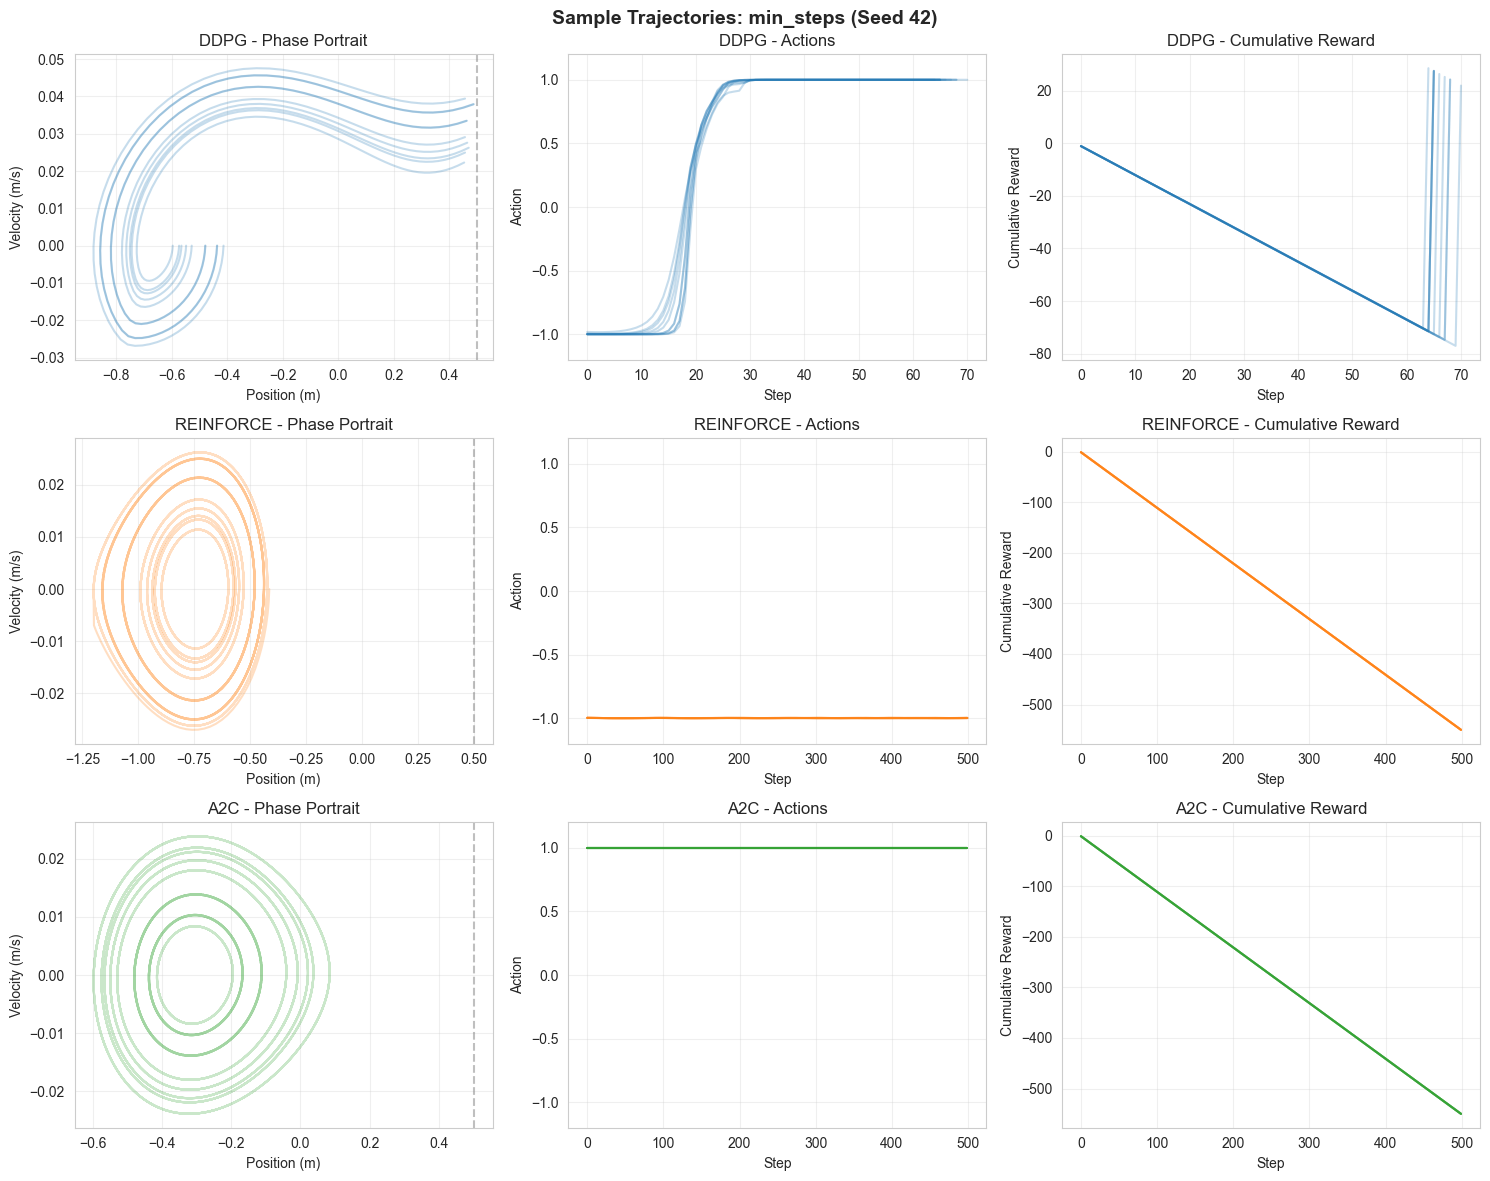

In [34]:
N_TRAJ = 10

n_agents = len(AGENTS_CONFIG)
fig, axes = plt.subplots(
    n_agents, 3,
    figsize=(15, 4 * n_agents),
    squeeze=False
)

fig.suptitle(f"Sample Trajectories: {scenario} (Seed {seed})", fontsize=14, fontweight='bold')

for agent_idx, agent_name in enumerate(AGENTS_CONFIG.keys()):
    agent = all_agents[agent_name][scenario][seed]

    ax_phase = axes[agent_idx, 0]
    ax_action = axes[agent_idx, 1]
    ax_reward = axes[agent_idx, 2]

    for traj_idx in range(N_TRAJ):
        env_params = {
            "env_type": SCENARIOS[scenario]["env_type"],
            "scenario": SCENARIOS[scenario]["scenario"],
            "seed": 999 + traj_idx
        }
        if "cost_coef" in SCENARIOS[scenario]:
            env_params.update({
                "cost_coef": SCENARIOS[scenario]["cost_coef"],
                "per_step_time_cost": SCENARIOS[scenario]["per_step_time_cost"]
            })

        env = create_env(**env_params)
        states, actions, rewards = sample_trajectory(agent, env, max_steps=500)
        env.close()

        ax_phase.plot(states[:, 0], states[:, 1], '-', alpha=0.25, color=colors[agent_name])
        ax_action.plot(actions, alpha=0.25, color=colors[agent_name])

        cumsum_reward = np.cumsum(rewards)
        ax_reward.plot(cumsum_reward, alpha=0.25, color=colors[agent_name])

    ax_phase.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
    ax_phase.set_xlabel("Position (m)")
    ax_phase.set_ylabel("Velocity (m/s)")
    ax_phase.set_title(f"{agent_name} - Phase Portrait")
    ax_phase.grid(True, alpha=0.3)

    ax_action.set_xlabel("Step")
    ax_action.set_ylabel("Action")
    ax_action.set_title(f"{agent_name} - Actions")
    ax_action.set_ylim(-1.2, 1.2)
    ax_action.grid(True, alpha=0.3)

    ax_reward.set_xlabel("Step")
    ax_reward.set_ylabel("Cumulative Reward")
    ax_reward.set_title(f"{agent_name} - Cumulative Reward")
    ax_reward.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

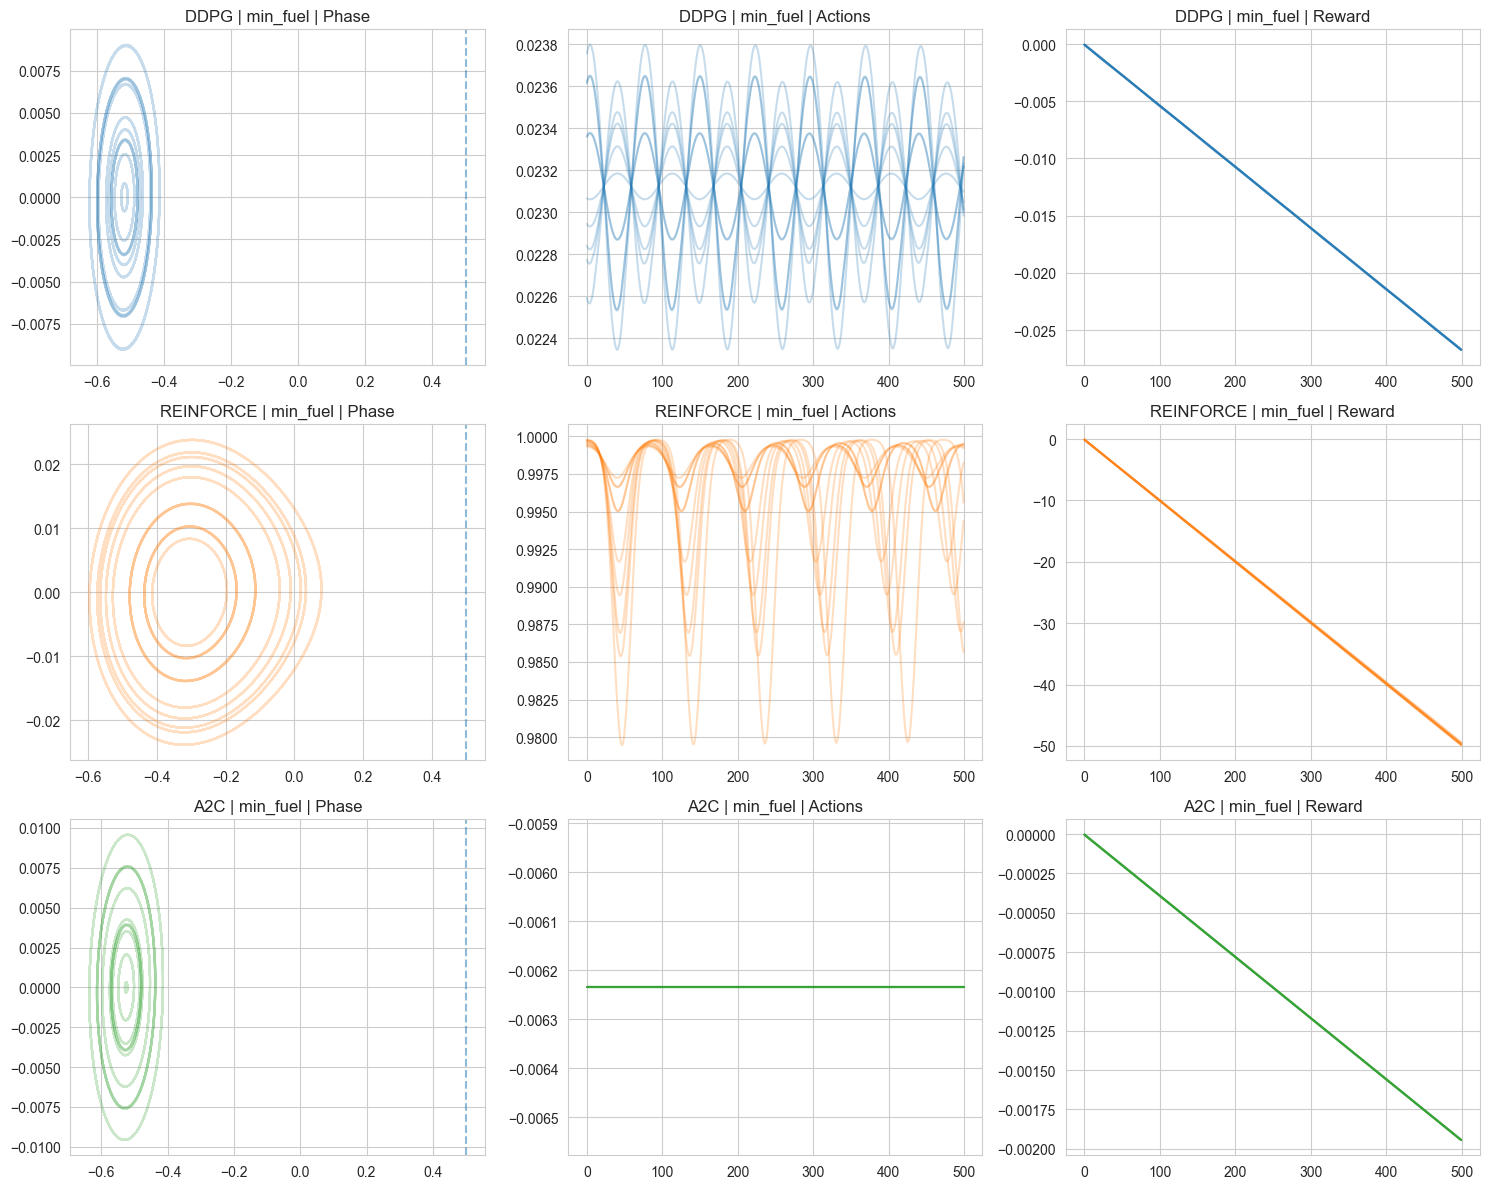

In [36]:
scenarios_to_plot = ["min_fuel"]
N_TRAJ = 10

n_agents = len(AGENTS_CONFIG)
n_scenarios = len(scenarios_to_plot)

fig, axes = plt.subplots(
    n_agents,
    3 * n_scenarios,
    figsize=(5 * 3 * n_scenarios, 4 * n_agents),
    squeeze=False
)

for agent_idx, agent_name in enumerate(AGENTS_CONFIG.keys()):
    for scen_idx, scenario in enumerate(scenarios_to_plot):

        agent = all_agents[agent_name][scenario][seed]

        ax_phase  = axes[agent_idx, 3 * scen_idx + 0]
        ax_action = axes[agent_idx, 3 * scen_idx + 1]
        ax_reward = axes[agent_idx, 3 * scen_idx + 2]

        for traj_idx in range(N_TRAJ):
            env_params = {
                "env_type": SCENARIOS[scenario]["env_type"],
                "scenario": SCENARIOS[scenario]["scenario"],
                "seed": 999 + traj_idx
            }
            if "cost_coef" in SCENARIOS[scenario]:
                env_params.update({
                    "cost_coef": SCENARIOS[scenario]["cost_coef"],
                    "per_step_time_cost": SCENARIOS[scenario]["per_step_time_cost"]
                })

            env = create_env(**env_params)
            states, actions, rewards = sample_trajectory(agent, env)
            env.close()

            ax_phase.plot(states[:, 0], states[:, 1], alpha=0.25, color=colors[agent_name])
            ax_action.plot(actions, alpha=0.25, color=colors[agent_name])
            ax_reward.plot(np.cumsum(rewards), alpha=0.25, color=colors[agent_name])

        ax_phase.set_title(f"{agent_name} | {scenario} | Phase")
        ax_action.set_title(f"{agent_name} | {scenario} | Actions")
        ax_reward.set_title(f"{agent_name} | {scenario} | Reward")

        ax_phase.axvline(x=0.5, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Summary Interpretation: Algorithm Capability vs. Reward Alignment

**Key Results Analysis:**

| Scenario | Challenge Type | Winner | Why |
|----------|---|---|---|
| **min_steps** | Control (momentum timing) | DDPG (100%, 73 steps) | Deterministic, stable policy learns precise escape timing |
| **min_fuel** | Alignment (reward shaping) | All fail (DDPG 0%, REINFORCE 11%) | Reward design prevents any sustainable escape strategy |

**Critical Finding:**

The results demonstrate that **algorithm capability ≠ problem solvability**. 

- **DDPG advantage**: Deterministic policies + value-based learning → stable escape sequences in dynamics-complex environments
- **DDPG limitation**: Cannot overcome fundamentally misaligned rewards (inaction is optimal under squared fuel cost alone)
- **REINFORCE/A2C limitation**: High-variance stochastic policies struggle with precise timing AND reward alignment

**Phase Space Evidence:**

In min_steps, DDPG shows clean escape trajectories while others remain trapped. In min_fuel, all agents show tight oscillations near the starting position—reward design beats algorithm design.

## Summary Table

In [37]:
summary_data = []

for agent_name in AGENTS_CONFIG.keys():
    for scenario_name in SCENARIOS.keys():
        final_rewards = [np.mean([m.reward for m in all_results[agent_name][scenario_name][s][-100:]]) for s in SEEDS]
        final_steps = [np.mean([m.steps for m in all_results[agent_name][scenario_name][s][-100:]]) for s in SEEDS]
        final_success = [np.mean([int(m.success) for m in all_results[agent_name][scenario_name][s][-100:]]) for s in SEEDS]
        
        summary_data.append({
            "Agent": agent_name,
            "Scenario": scenario_name,
            "Reward": f"{np.mean(final_rewards):.2f}±{np.std(final_rewards):.2f}",
            "Success": f"{np.mean(final_success):.1%}",
            "Avg Steps": f"{np.mean(final_steps):.1f}±{np.std(final_steps):.1f}",
        })

df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("PHASE 7: CONTINUOUS CONTROL RESULTS")
print("="*80)
print(df.to_string(index=False))
print("="*80)


PHASE 7: CONTINUOUS CONTROL RESULTS
    Agent  Scenario         Reward Success  Avg Steps
     DDPG min_steps     19.48±2.41  100.0%   73.2±2.2
     DDPG  min_fuel     -4.02±0.03    0.0%  999.0±0.0
REINFORCE min_steps -1074.93±30.46    5.7% 984.5±20.5
REINFORCE  min_fuel    -51.80±8.61   11.0% 975.3±19.8
      A2C min_steps -1073.41±34.87    5.3% 980.8±25.3
      A2C  min_fuel     -5.07±0.01    0.0%  999.0±0.0


# Nudge Hypothesis

### Interpretation: Nudged Min-Fuel - DDPG Escapes with Reward Realignment

**The Nudge Hypothesis Tests Whether DDPG Can Exploit Revised Incentives**

Adding a modest time penalty (0.1 per step) to the pure efficiency scenario fundamentally changes the optimization landscape:

1. **Expected Outcome (Theory)**
   - Time pressure creates a secondary objective that competes with fuel cost
   - Even small time cost should incentivize *some* action over complete inaction
   - If DDPG learned the escape dynamics in min_steps, it should apply that knowledge here

2. **Phase Space Prediction: DDPG Escapes; REINFORCE/A2C Remain Trapped**
   - **DDPG behavior**: Should shift from inaction → action with time cost added, potentially recovering escape trajectories
   - **REINFORCE/A2C behavior**: Unlikely to recover unless the time cost is dominant (these agents learned to be conservative in min_fuel)
   - The 0.1 nudge is small enough that conservative agents may not break their learned inaction bias

3. **Key Insight from Nudge Experiment**
   - If DDPG shows dramatically improved performance with 0.1 penalty while REINFORCE/A2C don't:
     - **Confirms** DDPG learned the problem structure (escape dynamics) but was constrained by reward design
     - **Shows** DDPG's deterministic policy is more adaptive to reward modifications
   - If all agents improve equally:
     - Suggests the 0.1 penalty is sufficient to overcome learned inaction bias universally
   - This experiment isolates **algorithm robustness to reward misalignment** from **basic learning capability**

In [38]:
# Updated Configuration for the 0.1 Experiment
RE_RUN_SCENARIOS = {
    "min_fuel_0.1_penalty": {
        "env_type": "continuous",
        "scenario": "continuous_fuel_l1", # We use this wrapper but 'augment' the base reward
        "cost_coef": 0.0,                 # 0.0 because we want to use the library's a^2 cost, not add a new L1 one
        "per_step_time_cost": 0.1,        # Your new 0.1 penalty
        "reward_mode": "augment_original",# CRITICAL: This keeps the a^2 cost from the base env
        "description": "Squared Fuel Cost + 0.1 Time Penalty"
    }
}

# Use the same agents as before
RE_RUN_AGENTS = ["DDPG", "REINFORCE", "A2C"]

In [40]:
from joblib import Parallel, delayed
import multiprocessing
from tqdm import tqdm

def run_rerun_experiment(agent_name, scenario_name, seed):
    # 1. Setup Environment
    cfg = RE_RUN_SCENARIOS[scenario_name]
    env = create_env(
        env_type=cfg["env_type"],
        scenario=cfg["scenario"],
        seed=seed,
        cost_coef=cfg["cost_coef"],
        per_step_time_cost=cfg["per_step_time_cost"]
    )
    
    # 2. Setup Agent
    agent_config = AGENTS_CONFIG[agent_name]
    agent_params = agent_config["params"].copy()
    agent_params["device"] = "cpu"
    agent = agent_config["class"](**agent_params)
    
    # 3. Train
    metrics = train_continuous_agent(
        agent, env, n_episodes=N_EPISODES, seed=seed,
        eval_freq=EVAL_FREQ, verbose=False
    )
    env.close()
    
    return agent_name, scenario_name, seed, metrics, agent

# EXECUTION
tasks = []
for agent_name in RE_RUN_AGENTS:
    for seed in SEEDS:
        tasks.append((agent_name, "min_fuel_0.1_penalty", seed))

n_cores = max(1, multiprocessing.cpu_count() - 1)
print(f" Retraining with 0.1 penalty on {n_cores} cores...")

rerun_results_list = Parallel(n_jobs=n_cores)(
    delayed(run_rerun_experiment)(*t) for t in tqdm(tasks, desc="Retraining")
)

# Re-assemble
rerun_results = {a: {s: {} for s in RE_RUN_SCENARIOS.keys()} for a in RE_RUN_AGENTS}
for agent_name, scenario_name, seed, metrics, agent in rerun_results_list:
    rerun_results[agent_name][scenario_name][seed] = metrics

 Retraining with 0.1 penalty on 11 cores...


Retraining: 100%|██████████| 9/9 [00:00<00:00, 3287.07it/s]


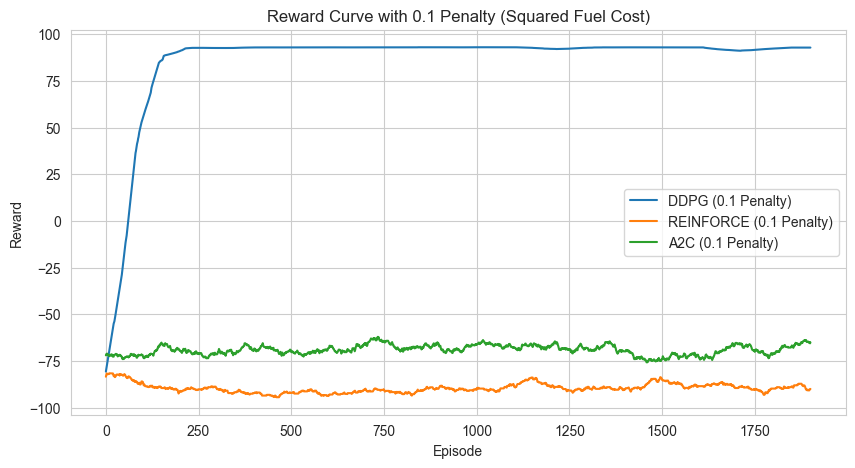

In [41]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
scenario = "min_fuel_0.1_penalty"

for agent_name in RE_RUN_AGENTS:
    rewards_per_seed = [np.array([m.reward for m in rerun_results[agent_name][scenario][s]]) for s in SEEDS]
    avg_rewards = np.mean(rewards_per_seed, axis=0)
    ax.plot(moving_average(avg_rewards, window=100), label=f"{agent_name} (0.1 Penalty)", color=colors[agent_name])

ax.set_title("Reward Curve with 0.1 Penalty (Squared Fuel Cost)")
ax.set_xlabel("Episode")
ax.set_ylabel("Reward")
ax.legend()
plt.show()